# Single-Run Evaluation Analysis

Coverage by schema for each dataset, broken down by generation model.

**Source:** `outputs/evaluation/single_run/{evaluator}/{generator}/{dataset}/evaluation.json`

In [8]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

_cwd = Path.cwd()
ROOT = _cwd if (_cwd / "pyproject.toml").exists() else _cwd.parent
SINGLE_RUN_DIR = ROOT / "outputs" / "evaluation" / "single_run"
FIGURES_DIR = ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(context="paper", style="ticks")
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

## Load data

In [9]:
records = []
for path in sorted(SINGLE_RUN_DIR.glob("**/evaluation.json")):
    # path: single_run/{evaluator}/{generator}/{dataset}/evaluation.json
    dataset   = path.parent.name
    generator = path.parent.parent.name
    evaluator = path.parent.parent.parent.name
    ed = json.loads(path.read_text())
    for schema in ed["evaluations"]:
        cov, hc = [], []
        for expert in schema["experts"]:
            t = expert["total_questions"]
            if t:
                cov.append(expert["covered_questions"] / t)
                hc.append(expert["high_confidence"] / t)
        if cov:
            records.append({
                "evaluator":    evaluator,
                "generator":    generator,
                "dataset":      dataset,
                "schema_index": schema["schema_index"],
                "num_fields":   schema["num_fields"],
                "coverage":     float(np.mean(cov)),
                "high_conf":    float(np.mean(hc)),
            })

df = pd.DataFrame(records)
print(
    f"{len(df)} schema evaluations · "
    f"{df['dataset'].nunique()} dataset(s) · "
    f"{df['generator'].nunique()} generator model(s)"
)
df.head()

162 schema evaluations · 3 dataset(s) · 6 generator model(s)


,evaluator,generator,dataset,schema_index,num_fields,coverage,high_conf
0,gpt-5.4-mini,claude-sonnet-4.6,pl_age,0,1,0.806206,0.772873
1,gpt-5.4-mini,claude-sonnet-4.6,pl_age,1,1,0.841141,0.832132
2,gpt-5.4-mini,claude-sonnet-4.6,pl_age,2,1,0.861261,0.831632
3,gpt-5.4-mini,claude-sonnet-4.6,pl_age,3,1,0.849650,0.849650
4,gpt-5.4-mini,claude-sonnet-4.6,pl_age,4,1,0.870270,0.850150


## Table — coverage by schema

In [10]:
table = (
    df[["dataset", "generator", "schema_index", "num_fields", "coverage", "high_conf"]]
    .sort_values(["dataset", "generator", "schema_index"])
    .reset_index(drop=True)
)
table.index += 1

styled = (
    table.style
    .format({
        "num_fields": "{:.0f}",
        "coverage":   "{:.1%}",
        "high_conf":  "{:.1%}",
    })
    .background_gradient(subset=["coverage", "high_conf"], cmap="RdYlGn", vmin=0, vmax=1)
    .set_caption(
        "Coverage and high-confidence rate per schema (mean across expert question sets)."
    )
    .set_table_styles([
        {"selector": "caption", "props": "font-size:0.85em; text-align:left; padding-bottom:4px;"},
        {"selector": "th", "props": "text-align:center; font-weight:bold;"},
        {"selector": "td", "props": "text-align:center;"},
    ])
)
# display(styled)

# LaTeX export for paper
latex = (
    table
    .assign(
        coverage=lambda d: d["coverage"].map("{:.1%}".format),
        high_conf=lambda d: d["high_conf"].map("{:.1%}".format),
        num_fields=lambda d: d["num_fields"].astype(int),
    )
    .rename(columns={
        "dataset": "Dataset",
        "generator": "Generator",
        "schema_index": "Schema",
        "num_fields": "Fields",
        "coverage": "Coverage",
        "high_conf": "High conf.",
    })
    .to_latex(index=False, column_format="llccrr")
)
out_tex = FIGURES_DIR / "single_run_coverage_table.tex"
# out_tex.write_text(latex)
# print(f"LaTeX table saved: {out_tex}")
# print(latex)

## Figure — coverage by schema

Saved: /home/asawczyn/dev/schematize/outputs/figures/single_run_coverage_by_schema.pdf


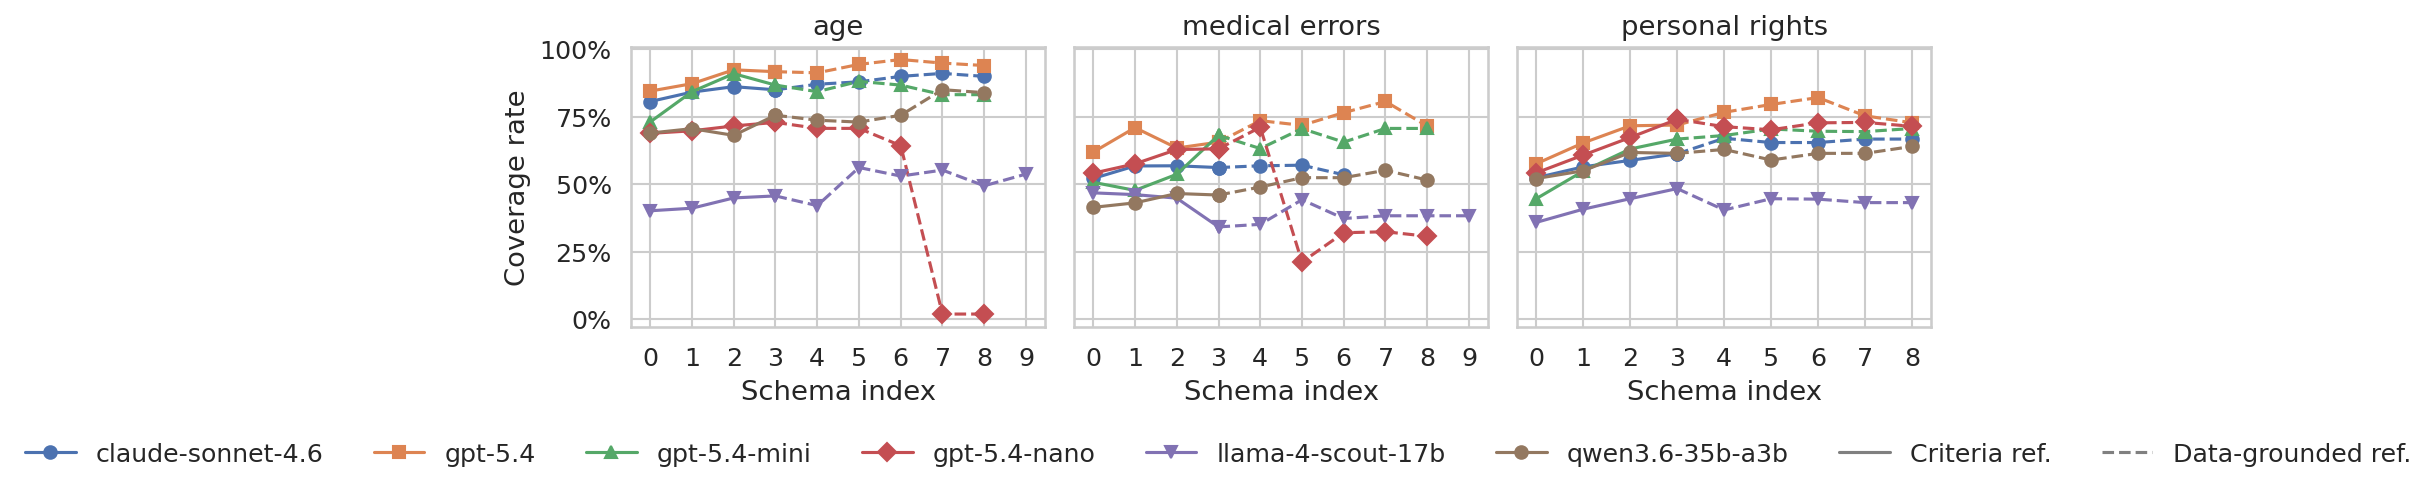

In [11]:
import matplotlib.lines as mlines
import re

def fmt_label(name: str) -> str:
    return re.sub(r"^[a-z]{2}_", "", name).replace("_", " ")

datasets   = sorted(df["dataset"].unique())
generators = sorted(df["generator"].unique())

palette    = sns.color_palette(n_colors=len(generators))
markers    = ["o", "s", "^", "D", "v"]
color_map  = {g: palette[i % len(palette)] for i, g in enumerate(generators)}
marker_map = {g: markers[i % len(markers)] for i, g in enumerate(generators)}

# All runs in this dataset have 3 criteria rounds (indices 0-3) followed by data-grounded
# rounds (index 4+). The criteria boundary is fixed but data rounds can vary per run.
CRITERIA_END = 3

col_w = 3.3
ncols = len(datasets)

sns.set_theme(style="whitegrid", font_scale=1.1)

fig, axes = plt.subplots(1, ncols, figsize=(col_w * ncols, 3.0), sharey=True)
if ncols == 1:
    axes = [axes]

for ax, dataset in zip(axes, datasets):
    sub = df[df["dataset"] == dataset]
    for gen in generators:
        g = sub[sub["generator"] == gen].sort_values("schema_index")
        kw = dict(marker=marker_map[gen], color=color_map[gen])
        ax.plot(g[g["schema_index"] <= CRITERIA_END]["schema_index"],
                g[g["schema_index"] <= CRITERIA_END]["coverage"],
                linestyle="-", label=gen, **kw)
        ax.plot(g[g["schema_index"] >= CRITERIA_END]["schema_index"],
                g[g["schema_index"] >= CRITERIA_END]["coverage"],
                linestyle="--", label="_nolegend_", **kw)

    ax.set_title(fmt_label(dataset))
    ax.set_xlabel("Schema index")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

axes[0].set_ylabel("Coverage rate")

gen_handles, gen_labels = axes[0].get_legend_handles_labels()
stage_handles = [
    mlines.Line2D([], [], color="gray", linestyle="-",  label="Criteria ref."),
    mlines.Line2D([], [], color="gray", linestyle="--", label="Data-grounded ref."),
]

fig.tight_layout()
fig.legend(
    gen_handles + stage_handles,
    gen_labels + [h.get_label() for h in stage_handles],
    loc="lower center",
    ncol=len(generators) + 2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.12),
)

out_pdf = FIGURES_DIR / "single_run_coverage_by_schema.pdf"
out_png = FIGURES_DIR / "single_run_coverage_by_schema.png"
fig.savefig(out_pdf, bbox_inches="tight")
fig.savefig(out_png, bbox_inches="tight")
print(f"Saved: {out_pdf}")
plt.show()

## Table — final coverage (last schema)

In [12]:
last_idx = df.groupby(["evaluator", "generator", "dataset"])["schema_index"].transform("max")
final_df = df[df["schema_index"] == last_idx]

pivot = (
    final_df.groupby(["generator", "dataset"])["coverage"]
    .mean()
    .unstack("dataset")
    .rename(columns=lambda c: fmt_label(c))
)

styled_final = (
    pivot.style
    .format("{:.1%}")
    .set_caption("Coverage rate — final schema (mean across evaluators and expert question sets).")
    .set_table_styles([
        {"selector": "caption", "props": "font-size:0.85em; text-align:left; padding-bottom:4px;"},
        {"selector": "th", "props": "text-align:center; font-weight:bold;"},
        {"selector": "td", "props": "text-align:center;"},
    ])
)
display(styled_final)

print(
    pivot
    .rename_axis("Generator")
    .rename_axis(None, axis=1)
    .map("{:.1%}".format)
    .to_latex(column_format="l" + "c" * len(pivot.columns))
)

dataset,age,medical errors,personal rights
generator,,,
claude-sonnet-4.6,89.9%,53.5%,66.7%
gpt-5.4,94.0%,71.5%,72.8%
gpt-5.4-mini,83.2%,70.6%,70.6%
gpt-5.4-nano,1.9%,30.7%,71.4%
llama-4-scout-17b,53.7%,38.3%,43.2%
qwen3.6-35b-a3b,83.9%,51.5%,64.0%


\begin{tabular}{lccc}
\toprule
 & age & medical errors & personal rights \\
Generator &  &  &  \\
\midrule
claude-sonnet-4.6 & 89.9% & 53.5% & 66.7% \\
gpt-5.4 & 94.0% & 71.5% & 72.8% \\
gpt-5.4-mini & 83.2% & 70.6% & 70.6% \\
gpt-5.4-nano & 1.9% & 30.7% & 71.4% \\
llama-4-scout-17b & 53.7% & 38.3% & 43.2% \\
qwen3.6-35b-a3b & 83.9% & 51.5% & 64.0% \\
\bottomrule
\end{tabular}



## Table — cost analysis per generation

In [13]:
GENERATED_DIR = ROOT / "outputs" / "generated_schemas"

# Price per 1M tokens (input, cached_input, output) — short context
PRICING = {
    "gpt-5.4":           (2.50,  0.250, 15.00),
    "gpt-5.4-mini":      (0.75,  0.075,  4.50),
    "gpt-5.4-nano":      (0.20,  0.020,  1.25),
    "claude-sonnet-4.6": (3.00,  0.300, 15.00),
}

cost_records = []
for p in sorted(GENERATED_DIR.glob("*/*/state.json")):
    generator = p.parent.parent.name
    dataset   = p.parent.name
    usage     = json.loads(p.read_text()).get("token_usage", [])
    in_tok    = sum(u["input_tokens"]  for u in usage)
    out_tok   = sum(u["output_tokens"] for u in usage)
    cache_tok = sum(u.get("input_token_details", {}).get("cache_read", 0) for u in usage)
    price     = PRICING.get(generator)
    if price:
        p_in, p_cache, p_out = price
        cost = ((in_tok - cache_tok) * p_in + cache_tok * p_cache + out_tok * p_out) / 1e6
    else:
        cost = None
    cost_records.append({
        "generator":   generator,
        "dataset":     fmt_label(dataset),
        "input_tok":   in_tok,
        "cache_tok":   cache_tok,
        "output_tok":  out_tok,
        "cost_usd":    cost,
    })

cost_df = pd.DataFrame(cost_records)

show_cost = cost_df["cost_usd"].notna().any()
value_col = "cost_usd" if show_cost else "input_tok"
fmt       = "${:.3f}" if show_cost else "{:,.0f}"
caption   = "Estimated generation cost (USD, short-context pricing, cache discounts applied)."

pivot_cost = cost_df.pivot_table(index="generator", columns="dataset", values=value_col)
pivot_cost["Mean"] = pivot_cost.mean(axis=1)

styled_cost = (
    pivot_cost.style
    .format(fmt)
    .set_caption(caption)
    .set_table_styles([
        {"selector": "caption", "props": "font-size:0.85em; text-align:left; padding-bottom:4px;"},
        {"selector": "th", "props": "text-align:center; font-weight:bold;"},
        {"selector": "td", "props": "text-align:center;"},
    ])
)
display(styled_cost)

print(
    pivot_cost
    .rename_axis("Generator")
    .rename_axis(None, axis=1)
    .map(fmt.format)
    .to_latex(column_format="l" + "c" * len(pivot_cost.columns))
)

dataset,age,medical errors,personal rights,Mean
generator,,,,
claude-sonnet-4.6,$3.637,$2.680,$2.853,$3.057
gpt-5.4,$3.562,$4.142,$3.651,$3.785
gpt-5.4-mini,$0.880,$0.842,$0.764,$0.828
gpt-5.4-nano,$0.221,$0.250,$0.232,$0.234


\begin{tabular}{lcccc}
\toprule
 & age & medical errors & personal rights & Mean \\
Generator &  &  &  &  \\
\midrule
claude-sonnet-4.6 & $3.637 & $2.680 & $2.853 & $3.057 \\
gpt-5.4 & $3.562 & $4.142 & $3.651 & $3.785 \\
gpt-5.4-mini & $0.880 & $0.842 & $0.764 & $0.828 \\
gpt-5.4-nano & $0.221 & $0.250 & $0.232 & $0.234 \\
\bottomrule
\end{tabular}



In [14]:
# Todo: tables with stats:
#  num of fields, distribution of types
# cost per generation